# Feature Representation Learning

Feature representation learning is the process of automatically discovering useful representations of raw data for machine learning tasks.

Instead of manually designing every feature, a learning algorithm can discover transformations that make the underlying structure of the data easier to model.

This notebook covers:

- Feature engineering vs representation learning
- Learned feature transformations
- Polynomial and interaction representations
- Dimensionality reduction
- Autoencoders
- Sparse and denoising representations
- Convolutional representations
- Embeddings
- Supervised representation learning
- Transfer learning
- Visualization of learned representations
- Evaluating representation quality
- Practical implementation with Python and scikit-learn

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain what feature representation learning means.
2. Distinguish feature engineering from representation learning.
3. Understand why good representations can simplify machine learning.
4. Construct nonlinear feature representations.
5. Understand dimensionality reduction as representation learning.
6. Explain the architecture of an autoencoder.
7. Understand sparse and denoising autoencoders.
8. Understand embeddings as learned representations.
9. Explain how neural networks learn hierarchical representations.
10. Visualize high-dimensional representations.
11. Evaluate whether a learned representation is useful.
12. Identify common failure modes of representation learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_moons,
    make_blobs,
    load_digits
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    mean_squared_error
)

from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings("ignore")

## What Is a Representation?

A representation is a numerical description of an observation that exposes information useful for a machine learning task.

Suppose the original observation is represented by:

$$
x \in \mathbb{R}^{d}
$$

A representation-learning algorithm transforms the original observation into another feature space:

$$
r = g(x)
$$
```text
where:

- x is the original input,
- g is a learned or predefined transformation,
- r is the resulting representation.

The goal is not simply to transform the data.

The goal is to learn a representation in which important structure becomes easier to identify, predict, or reconstruct.

## Why Representation Learning?

Raw data is often not expressed in a form that is convenient for machine learning.

Examples:

- Images are represented as pixels.
- Audio is represented as waveforms or spectrogram values.
- Text is represented as sequences of symbols.
- Sensor data may contain noisy measurements.
- Transaction data may contain many correlated variables.

A useful representation can:

- remove irrelevant variation,
- expose important structure,
- reduce dimensionality,
- capture nonlinear relationships,
- improve downstream prediction,
- improve generalization,
- make complex data easier to model.

A central idea is:

$$
\text{Raw Data}
\rightarrow
\text{Representation}
\rightarrow
\text{Prediction}
$$

The representation acts as an intermediate description of the original data.

## Feature Engineering vs Representation Learning

Traditional feature engineering relies heavily on human-designed transformations.

For example, from a person's height and weight, we might manually create:

$$
BMI = \frac{\text{weight}}{\text{height}^2}
$$

The transformation is specified by the human.

In representation learning, the transformation itself can be learned from data.

### Traditional Feature Engineering

$$
x
\rightarrow
\text{human-designed transformation}
\rightarrow
r
$$

### Representation Learning

$$
x
\rightarrow
\text{learning algorithm}
\rightarrow
r
$$

Representation learning therefore attempts to reduce the amount of manual feature construction required.

However, feature engineering and representation learning are not mutually exclusive.

Modern machine learning systems frequently combine:

- domain knowledge,
- preprocessing,
- engineered features,
- learned representations.

## Simple Feature Transformation

In [3]:
np.random.seed(42)

x = np.linspace(-3, 3, 100)

features = pd.DataFrame({
    "x": x,
    "x_squared": x**2,
    "x_cubed": x**3,
    "sin_x": np.sin(x)
})

features.head()

,x,x_squared,x_cubed,sin_x
0,-3.000000,9.000000,-27.000000,-0.141120
1,-2.939394,8.640037,-25.396472,-0.200824
2,-2.878788,8.287420,-23.857723,-0.259790
3,-2.818182,7.942149,-22.382419,-0.317802
4,-2.757576,7.604224,-20.969224,-0.374648


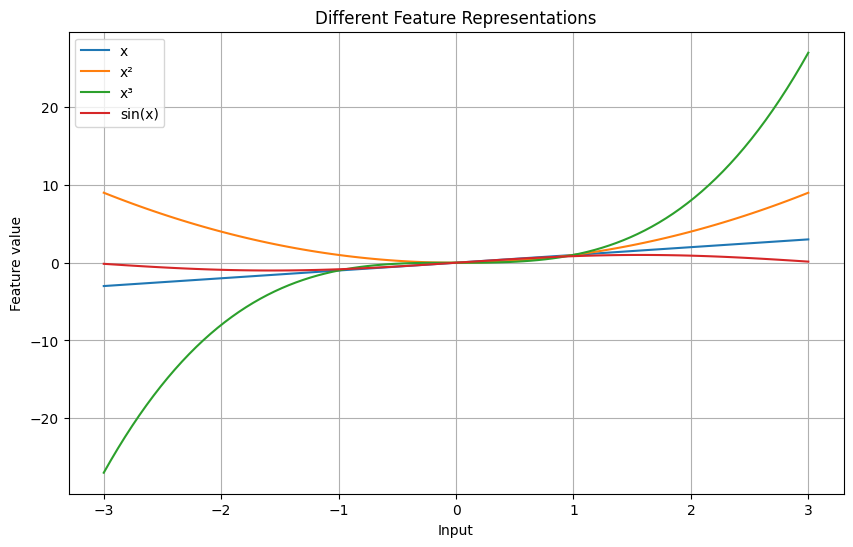

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(x, x, label="x")
plt.plot(x, x**2, label="x²")
plt.plot(x, x**3, label="x³")
plt.plot(x, np.sin(x), label="sin(x)")

plt.xlabel("Input")
plt.ylabel("Feature value")
plt.title("Different Feature Representations")
plt.legend()
plt.grid(True)
plt.show()

## Polynomial Feature Representations

A simple way to create richer representations is to construct polynomial features.

For two variables:

$$
x_1, x_2
$$

a second-degree polynomial representation can contain:

$$
1,\;
x_1,\;
x_2,\;
x_1^2,\;
x_1x_2,\;
x_2^2
$$

These additional features allow a linear model to represent certain nonlinear relationships.

The important idea is that the model can remain linear in the transformed feature space even though the relationship with the original variables is nonlinear.

In [5]:
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5]
])

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["x1", "x2"])

pd.DataFrame(
    X_poly,
    columns=feature_names
)

,x1,x2,x1^2,x1 x2,x2^2
0,1.0,2.0,1.0,2.0,4.0
1,2.0,3.0,4.0,6.0,9.0
2,3.0,4.0,9.0,12.0,16.0
3,4.0,5.0,16.0,20.0,25.0


## Interaction Features

Sometimes individual variables are not sufficient.

The relationship between two variables may depend on their interaction.

For example:

$$
x_1x_2
$$

captures an interaction between $$x_1$$ and $$x_2$$.

A representation may therefore contain:

$$
r =
[
x_1,
x_2,
x_1x_2
]
$$

This can make a difficult prediction problem easier for a downstream model.

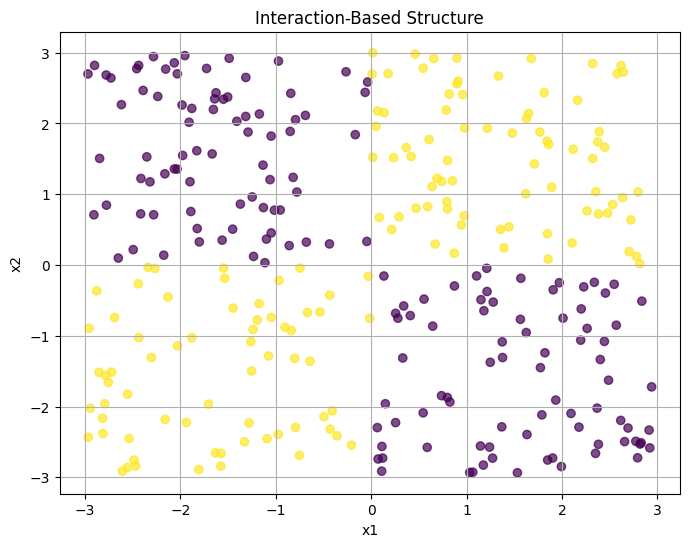

In [6]:
np.random.seed(42)

n = 300

x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)

y = (x1 * x2 > 0).astype(int)

X = np.column_stack([x1, x2])

plt.figure(figsize=(8, 6))

plt.scatter(
    x1,
    x2,
    c=y,
    alpha=0.7
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Interaction-Based Structure")
plt.grid(True)
plt.show()

## Nonlinear Representation

A representation does not have to be linear.

For example:

$$
r_1 = \sin(x_1)
$$

$$
r_2 = x_1^2
$$

$$
r_3 = x_1x_2
$$

can expose structure that is difficult to model directly from the original variables.

This motivates more powerful representation-learning systems, including neural networks.

## Dimensionality Reduction

Dimensionality reduction transforms a high-dimensional representation into a lower-dimensional one.

Suppose:

$$
x \in \mathbb{R}^{d}
$$

and we want a representation:

$$
r \in \mathbb{R}^{k}
$$

where:

$$
k < d
$$

The objective is often to preserve important information while reducing the number of dimensions.

Examples include:

- PCA
- Kernel PCA
- t-SNE
- UMAP
- Autoencoders

## PCA Representation

In [7]:
digits = load_digits()

X = digits.data
y = digits.target

print("Original shape:", X.shape)

Original shape: (1797, 64)


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Reduced shape: (1797, 2)


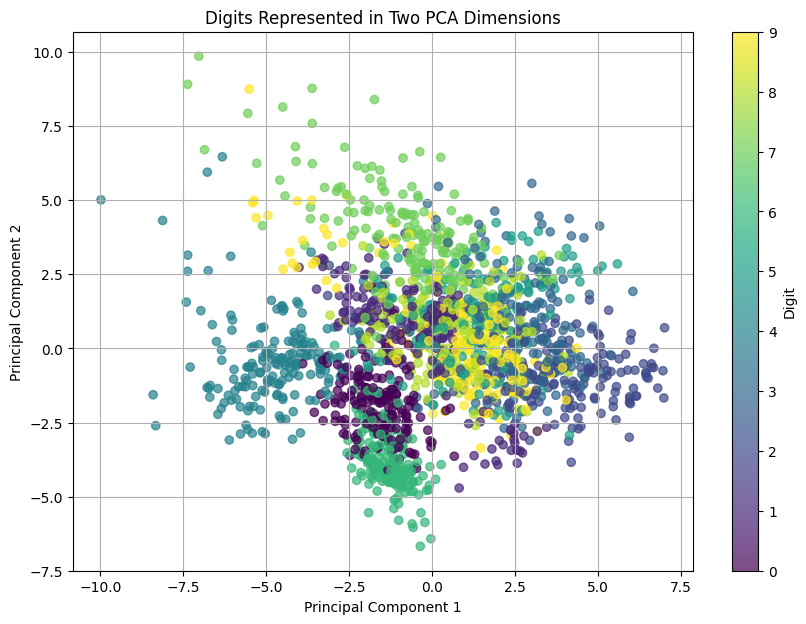

In [9]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Digits Represented in Two PCA Dimensions")
plt.colorbar(scatter, label="Digit")
plt.grid(True)
plt.show()

## PCA Explained Variance

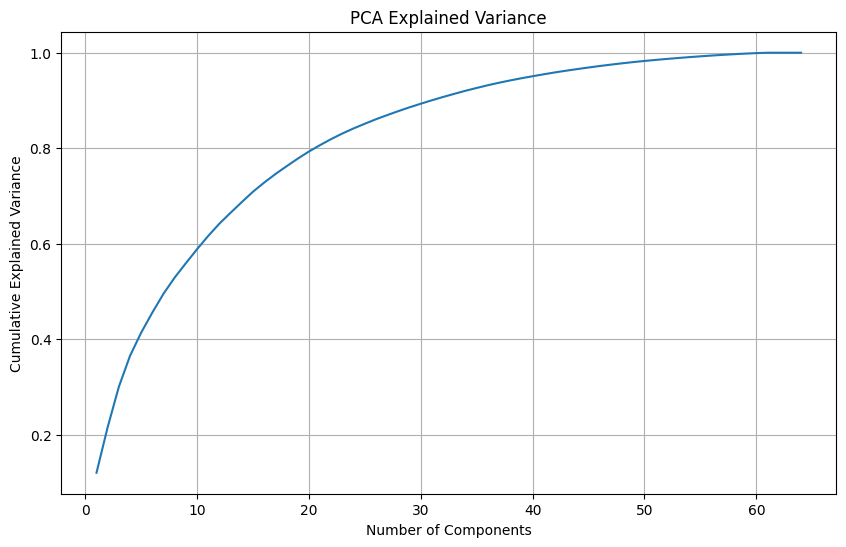

In [10]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

PCA provides a useful example of representation learning because it converts the original feature space into a new coordinate system.

The new coordinates are selected according to the variance structure of the data.

However, PCA is fundamentally a linear representation.

When the underlying structure is strongly nonlinear, nonlinear representation-learning methods can be more appropriate.

# Autoencoders

An autoencoder is a neural network trained to learn a compact representation of its input.

It contains two major components:

1. Encoder
2. Decoder

The encoder maps the input into a latent representation.

The decoder attempts to reconstruct the original input from that representation.

Conceptually:

$$
x
\rightarrow
\text{Encoder}
\rightarrow
r
\rightarrow
\text{Decoder}
\rightarrow
\hat{x}
$$

Training minimizes a reconstruction loss between the original input and reconstructed input.

For mean squared error:

$$
L =
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\hat{x}_i)^2
$$

The learned representation is the intermediate latent representation.

## Autoencoder Architecture

A simple architecture might look like:

$$
784
\rightarrow
128
\rightarrow
32
\rightarrow
128
\rightarrow
784
$$

For an image with 784 input values:

- 784 = input dimensionality
- 128 = hidden representation
- 32 = latent representation
- 128 = decoder hidden layer
- 784 = reconstructed output

The 32-dimensional latent space acts as a compressed representation.

The model must therefore learn which information is useful enough to preserve during reconstruction.

## Autoencoder on Digits

In [11]:
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(128, 32, 128),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42
)

autoencoder.fit(
    X_train,
    X_train
)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## Reconstruction

In [12]:
X_reconstructed = autoencoder.predict(X_test)

reconstruction_error = mean_squared_error(
    X_test,
    X_reconstructed
)

print("Reconstruction MSE:", reconstruction_error)

Reconstruction MSE: 0.07667987802828269


## Visualizing Reconstruction

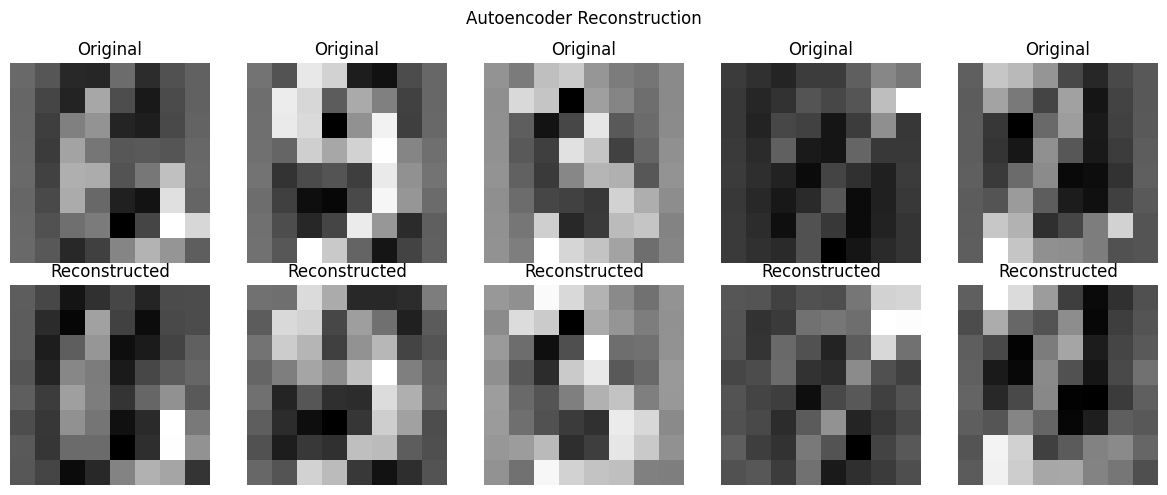

In [13]:
n_samples = 10

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flat):
    if i < 5:
        ax.imshow(
            X_test[i].reshape(8, 8),
            cmap="gray"
        )
        ax.set_title("Original")
    else:
        ax.imshow(
            X_reconstructed[i - 5].reshape(8, 8),
            cmap="gray"
        )
        ax.set_title("Reconstructed")

    ax.axis("off")

plt.suptitle("Autoencoder Reconstruction")
plt.tight_layout()
plt.show()

## What Does the Autoencoder Learn?

An autoencoder is not explicitly told:

> "These are the important features."

Instead, the representation emerges because the model must reconstruct the input.

If the latent representation is sufficiently constrained, the network must learn a compact encoding of the information needed for reconstruction.

This creates an important relationship:

$$
\text{Representation Quality}
\rightarrow
\text{Reconstruction Quality}
$$

However, good reconstruction does not automatically mean that the representation is optimal for every downstream task.

A representation can reconstruct data well while still being poor for classification or another specific objective.

## Undercomplete Autoencoder

An undercomplete autoencoder has a latent representation smaller than the original input.

If:

$$
d = 64
$$

and:

$$
k = 8
$$

then:

$$
k < d
$$

The model must compress the input.

This creates an information bottleneck.

The bottleneck encourages the model to retain important structure while discarding some information.

## Sparse Autoencoder

Another strategy is to encourage most latent units to remain inactive.

Suppose the latent representation is:

$$
r = [r_1, r_2, \ldots, r_k]
$$

A sparsity penalty encourages many values of $r$ to be close to zero.

The total objective can be viewed conceptually as:

$$
L = L_{\text{reconstruction}} + \lambda L_{\text{sparsity}}
$$

where:

- $L_{\text{reconstruction}}$ measures reconstruction error,
- $L_{\text{sparsity}}$ encourages sparse activations,
- $\lambda$ controls the strength of the sparsity constraint.

# Denoising Autoencoder

A denoising autoencoder receives a corrupted version of the input but is trained to reconstruct the original clean input.

The process is:

$$
x
\rightarrow
\tilde{x}
\rightarrow
\text{Encoder}
\rightarrow
r
\rightarrow
\text{Decoder}
\rightarrow
\hat{x}
$$

where:

$$
\tilde{x}
$$

is a corrupted version of:

$$
x
$$

The objective is:

$$
\hat{x} \approx x
$$

rather than:

$$
\hat{x} \approx \tilde{x}
$$

This encourages the representation to capture stable structure rather than simply memorizing noise.

## Noise Experiment

In [14]:
rng = np.random.default_rng(42)

noise = rng.normal(
    0,
    0.5,
    X_train.shape
)

X_noisy = X_train + noise

X_noisy = np.clip(
    X_noisy,
    -3,
    3
)

In [15]:
denoising_model = MLPRegressor(
    hidden_layer_sizes=(128, 32, 128),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42
)

denoising_model.fit(
    X_noisy,
    X_train
)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


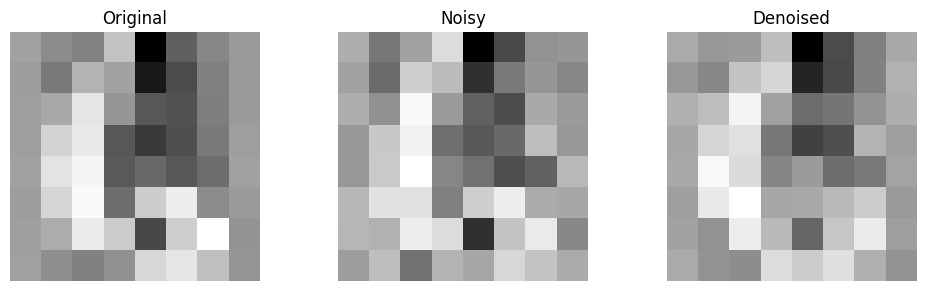

In [16]:
X_denoised = denoising_model.predict(X_noisy)

sample = 0

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10, 3)
)

axes[0].imshow(
    X_train[sample].reshape(8, 8),
    cmap="gray"
)
axes[0].set_title("Original")

axes[1].imshow(
    X_noisy[sample].reshape(8, 8),
    cmap="gray"
)
axes[1].set_title("Noisy")

axes[2].imshow(
    X_denoised[sample].reshape(8, 8),
    cmap="gray"
)
axes[2].set_title("Denoised")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Embeddings

An embedding is a learned numerical representation of an object.

The object might be:

- a word,
- a sentence,
- a document,
- a user,
- a product,
- an image,
- a graph node,
- a categorical value.

Instead of representing an object using a sparse symbolic representation, an embedding maps it into a continuous vector space.

For example:

$$
\text{object}
\rightarrow
\mathbb{R}^{k}
$$

The objective is usually to arrange objects so that useful relationships are reflected by their positions in the learned space.

## One-Hot Encoding vs Embedding

Suppose we have four categories:

$$
A,\;B,\;C,\;D
$$

One-hot encoding produces:

$$
A=[1,0,0,0]
$$

$$
B=[0,1,0,0]
$$

$$
C=[0,0,1,0]
$$

$$
D=[0,0,0,1]
$$

Every category is equally distant from every other category under ordinary Euclidean distance.

An embedding could instead learn:

$$
A=[0.2,0.8]
$$

$$
B=[0.3,0.7]
$$

$$
C=[-0.8,0.1]
$$

$$
D=[-0.7,0.2]
$$

Now the geometry can encode relationships between categories.

# Hierarchical Representation Learning

Deep neural networks can learn multiple levels of representation.

For an image, early layers may learn simple patterns such as:

- edges,
- orientations,
- textures.

Intermediate layers may combine these into:

- shapes,
- contours,
- parts.

Later layers may represent:

- objects,
- semantic concepts,
- task-specific information.

Conceptually:

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Parts}
\rightarrow
\text{Objects}
$$

This hierarchy is one of the major reasons deep learning is powerful for unstructured data.

## Convolutional Representations

Convolutional neural networks learn spatial representations from images.

A convolution applies a learnable filter to local regions of the input.

A simplified operation can be represented as:

$$
z_{i,j}
=
\sum_{u}
\sum_{v}
w_{u,v}x_{i+u,j+v}
+
b
$$

The same filter is applied across different spatial locations.

This gives convolutional networks useful properties such as:

- local connectivity,
- parameter sharing,
- spatial structure preservation.

# Supervised Representation Learning

Representations do not always need to be learned using reconstruction.

A model can learn representations directly for a supervised objective.

Suppose:

$$
x
\rightarrow
r
\rightarrow
\hat{y}
$$

The representation $$r$$ is learned because it helps predict the target $$y$$.

The training objective might be:

$$
L =
L(y,\hat{y})
$$

The learned representation is therefore task-dependent.

This creates an important distinction:

### Unsupervised representation

The representation is learned without explicit target labels.

### Supervised representation

The representation is optimized using labeled targets.

# Transfer Learning

A learned representation can sometimes be reused for another task.

Suppose a model is first trained on a large dataset:

$$
D_{\text{source}}
$$

The learned representation can then be transferred to another dataset:

$$
D_{\text{target}}
$$

Conceptually:

$$
D_{\text{source}}
\rightarrow
\text{Pretrained Representation}
\rightarrow
D_{\text{target}}
$$

This is especially useful when the target dataset is relatively small.

Examples include:

- pretrained image models,
- pretrained language models,
- pretrained audio models.

Transfer learning works best when the source and target domains share useful structure.

## Representation Visualization

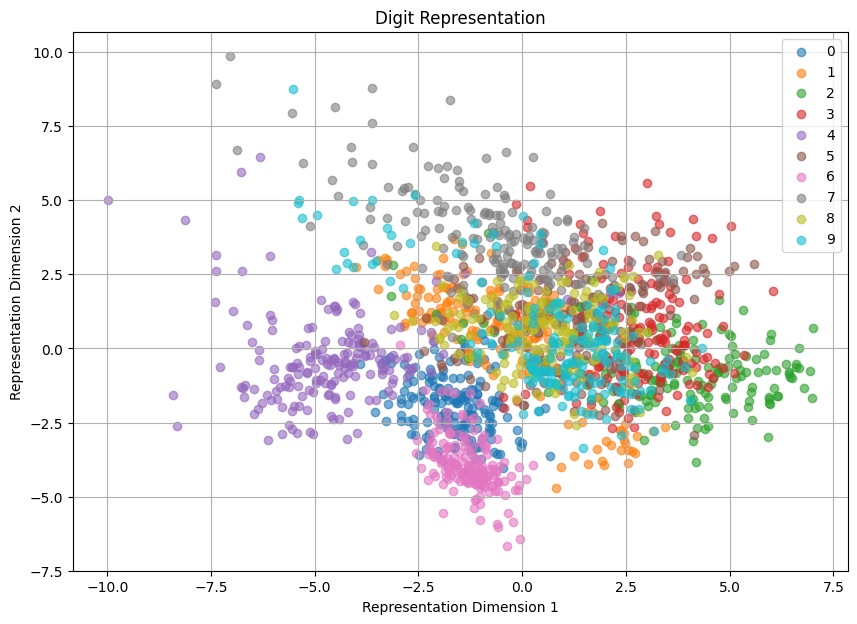

In [17]:
pca_2d = PCA(n_components=2)

X_digits_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for digit in range(10):
    mask = y == digit

    plt.scatter(
        X_digits_2d[mask, 0],
        X_digits_2d[mask, 1],
        label=str(digit),
        alpha=0.6
    )

plt.xlabel("Representation Dimension 1")
plt.ylabel("Representation Dimension 2")
plt.title("Digit Representation")
plt.legend()
plt.grid(True)
plt.show()

## t-SNE Representation

In [18]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(
    X_scaled[:1000]
)

y_tsne = y[:1000]

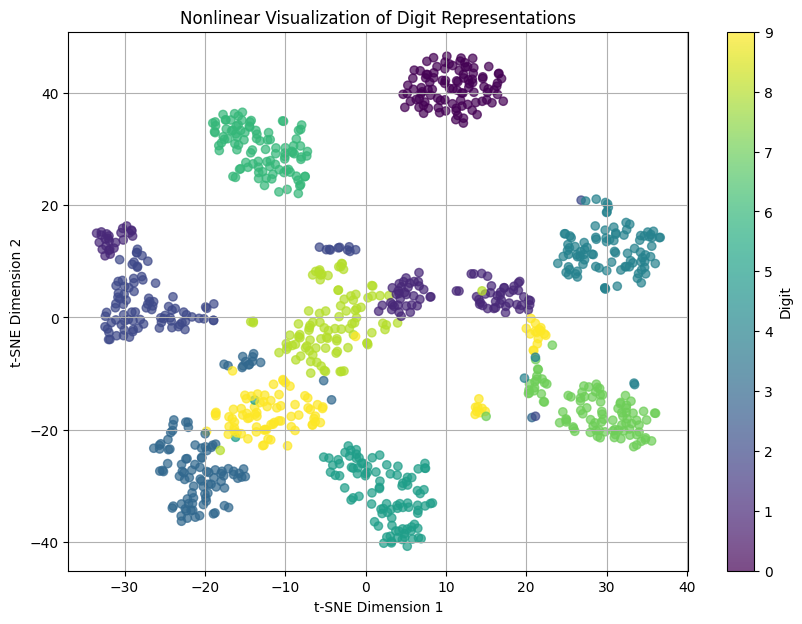

In [19]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_tsne,
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Nonlinear Visualization of Digit Representations")
plt.colorbar(scatter, label="Digit")
plt.grid(True)
plt.show()

# How Do We Evaluate a Representation?

A representation should be evaluated according to its intended purpose.

Possible criteria include:

### 1. Reconstruction quality

Can the representation preserve enough information to reconstruct the input?

$$
L_{\text{reconstruction}}
$$

### 2. Predictive performance

Does the representation improve downstream prediction?

### 3. Compression

Can the representation use fewer dimensions while retaining useful information?

### 4. Robustness

Does the representation remain useful when the input contains noise or small perturbations?

### 5. Separability

Do observations belonging to different classes become easier to distinguish?

### 6. Generalization

Does the representation remain useful on unseen data?

A visually attractive representation is not necessarily a useful representation.

## Linear Probe

One practical method for evaluating a learned representation is a linear probe.

First obtain representations:

$$
r = g(x)
$$

Then train a simple classifier:

$$
\hat{y} = h(r)
$$

where $$h$$ is deliberately kept simple, such as logistic regression.

If a simple classifier performs well, the representation likely contains information useful for the task.

This separates two questions:

1. Is useful information present in the representation?
2. Can a complicated classifier extract it?

A strong representation should ideally make the downstream task relatively easy.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pca = PCA(n_components=20)

X_train_repr = pca.fit_transform(X_train)
X_test_repr = pca.transform(X_test)

probe = LogisticRegression(
    max_iter=1000
)

probe.fit(
    X_train_repr,
    y_train
)

predictions = probe.predict(X_test_repr)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Linear probe accuracy:", accuracy)

Linear probe accuracy: 0.9388888888888889


# General Representation Learning Pipeline

A practical representation-learning workflow can be written as:

$$
\text{Raw Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Representation Learning}
\rightarrow
\text{Representation Evaluation}
\rightarrow
\text{Downstream Model}
$$

For example:

$$
X
\rightarrow
\text{Scaling}
\rightarrow
\text{PCA}
\rightarrow
Z
\rightarrow
\text{Logistic Regression}
\rightarrow
\hat{y}
$$

Or:

$$
X
\rightarrow
\text{Encoder}
\rightarrow
Z
\rightarrow
\text{Classifier}
\rightarrow
\hat{y}
$$

The representation should be evaluated as part of the entire machine-learning pipeline rather than judged in isolation.

# Failure Modes

Representation learning can fail in several ways.

## 1. Information loss

An excessively small representation may discard information required for the task.

## 2. Noise memorization

A high-capacity model may learn irrelevant variation instead of meaningful structure.

## 3. Data leakage

Representation learning must be fitted only on the training data when the representation-learning procedure learns from the dataset.

For example, PCA should generally be fitted on training data and then applied to validation and test data.

## 4. Poor objective

A representation optimized for reconstruction may not be optimal for classification.

## 5. Domain mismatch

A representation learned on one domain may not transfer well to another.

## 6. Interpretability

Learned representations can be difficult to interpret compared with carefully engineered features.

## 7. Overfitting

Representation-learning models can memorize training data when capacity is excessive relative to the available data.

# Representation Learning vs Feature Selection

Feature selection chooses a subset of existing features.

For example:

$$
[x_1,x_2,x_3,x_4,x_5]
\rightarrow
[x_1,x_3,x_5]
$$

The original feature meanings remain unchanged.

Representation learning instead creates new features:

$$
[x_1,x_2,x_3,x_4,x_5]
\rightarrow
[r_1,r_2,r_3]
$$

The new representation may combine information from many original variables.

Therefore:

$$
\text{Feature Selection}
\neq
\text{Representation Learning}
$$

although both can reduce dimensionality and improve downstream learning.

| Method | Main Idea | Linear? | Supervision | Typical Use |
|---|---|---:|---|---|
| Feature Engineering | Human-designed transformations | Sometimes | Optional | Domain-specific features |
| Feature Selection | Select existing features | Yes | Often | Reduce irrelevant variables |
| PCA | Variance-preserving projection | Yes | No | Compression, visualization |
| Kernel PCA | Nonlinear dimensionality reduction | No | No | Nonlinear structure |
| Autoencoder | Reconstruction-based representation | No | Usually no | Compression, denoising |
| Sparse Autoencoder | Sparse latent representation | No | Usually no | Feature discovery |
| Denoising Autoencoder | Reconstruct clean input | No | Usually no | Robust representations |
| Embeddings | Learn vector representations | Usually nonlinear | Depends | Text, users, products |
| CNN | Learn spatial representations | No | Usually yes | Images |
| Deep Networks | Hierarchical representations | No | Often yes | Complex prediction |

# The Big Picture

Representation learning can be viewed as learning a useful coordinate system for data.

Instead of asking only:

> Which model should we use?

we can also ask:

> In what representation does this problem become easier?

A complete system can therefore be viewed as:

$$
\text{Input}
\rightarrow
\boxed{\text{Representation}}
\rightarrow
\boxed{\text{Prediction}}
$$

Modern machine learning increasingly combines representation learning with powerful downstream models.

# Final Summary

Feature representation learning is a central idea in modern machine learning.

The fundamental idea is to transform raw observations into representations that expose useful structure.

We studied several approaches:

$$
\text{Raw Features}
\rightarrow
\begin{cases}
\text{Polynomial Features}\\
\text{Interaction Features}\\
\text{PCA}\\
\text{Autoencoders}\\
\text{Sparse Representations}\\
\text{Denoising Representations}\\
\text{Embeddings}\\
\text{Deep Hierarchical Representations}
\end{cases}
$$

The most important conceptual lesson is:

$$
\boxed{
\text{Better Representation}
\rightarrow
\text{Easier Learning}
}
$$

However, "better" depends on the task.

A representation that is excellent for reconstruction may not be optimal for classification, retrieval, clustering, or generation.

Therefore, representation learning should ultimately be evaluated according to the downstream problem it is intended to solve.